# Regression - ML algo + continous numerical values

# EX =Sal, house price, temp, sales

# classification - categories

# EX - Student passed 

# SLR - One dependent variable using one indipendent var

# SLR -One dependent variable using one independent variable 

# hours study                                 marks 
#   2                                          40
#   3                                          50
#   4                                          60
#   5                                          70

# Relationship btw hours and marks 
# Independent var - Hours
# Dependent var - Marks 

# y = mx+c
# y = predicted o/p
# x = Input
# m Slope
# c = Intercept

# EX - marks
# marks = 10 * 5+20 = 70

In [2]:
import pandas as pd # data handling 
import numpy as np # numerical calculation 
import matplotlib.pyplot as plt # visual graph plot 
from sklearn.model_selection import train_test_split # Random suffle, split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score # Evaluate 
from sklearn.datasets import load_diabetes
diabetes=load_diabetes()

In [3]:
print(type(diabetes))

<class 'sklearn.utils._bunch.Bunch'>


In [4]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [5]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [7]:
df = pd.DataFrame(
    diabetes.data,
    columns= diabetes.feature_names
)

In [8]:
df['target']= diabetes.target

In [9]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [10]:
df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [11]:
print("Row:", df.shape[0])

Row: 442


In [12]:
print("columns:", df.shape[1])

columns: 11


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [15]:
df.isnull().sum() # count null values 

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [16]:
df.duplicated().sum() # dupt

np.int64(0)

In [17]:
X = df[["bmi"]]
Y = df['target']

Note : use double brackett because we have to acces internal value 

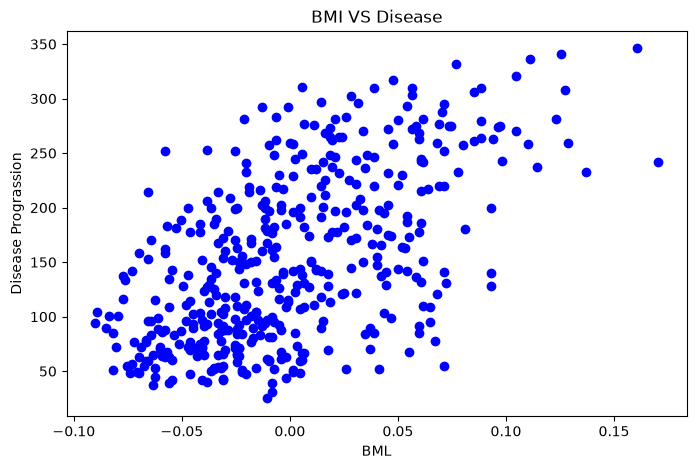

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y,color='blue')
plt.xlabel("BML")
plt.ylabel("Disease Prograssion")
plt.title("BMI VS Disease")
plt.show()

In [19]:
# X_train, X_test, Y_train, Y_test = train_test_split(
#     X,Y,test_size=0.2,
#     random_state = 42
# )

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [21]:
len(X_train)

353

In [22]:
len(X_test)

89

In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, Y_train) #train


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [25]:
y_pred = model.predict(X_test)

In [26]:
comparison = pd.DataFrame({
    "Actual":Y_test.values,
    "Predicted": y_pred
})
comparison.head(20)

,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


In [27]:
mae = mean_absolute_error(Y_test,y_pred) # it tells the average mistake 
mse = mean_squared_error(Y_test,y_pred) # errors more then panalty high 

In [28]:
r2 = r2_score(Y_test,y_pred) # accurate

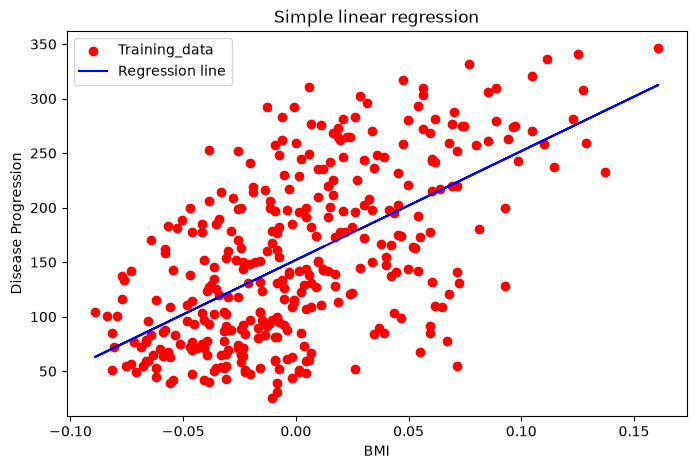

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(X_train,Y_train,color = "red", label="Training_data")
plt.plot(X_train, model.predict(X_train), color = "blue", label="Regression line")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple linear regression")
plt.legend()
plt.show()

In [30]:
new_b = [[0.04]]
prediction = model.predict(new_b)
print(prediction)

[191.94646178]


c:\Users\Gyanendra Shukla\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Hours              Marks 
# 1                  30
# 2                  40
# 3                  45
# 4                  55
# 5                  65
# 6                  72
# 7                  80
# 8                  88

In [31]:
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Marks": [30, 40, 45, 55, 65, 72, 80, 88]
}


In [32]:
df = pd.DataFrame(data)

In [33]:
X = df[["Hours"]]
Y = df["Marks"]

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [35]:
model = LinearRegression()

In [36]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.4]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [37]:
y_pred = model.predict(X_test)

In [38]:
result = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": y_pred
})

print(result)

   Actual  Predicted
0      40       38.1
1      72       71.7


In [39]:
score = r2_score(Y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.9927734375


In [40]:
# Predict for a new student 

new_student = pd.DataFrame({"Hours": [5.5]})
prediction = model.predict(new_student)

print("Predicted Marks:", prediction[0])

Predicted Marks: 67.5


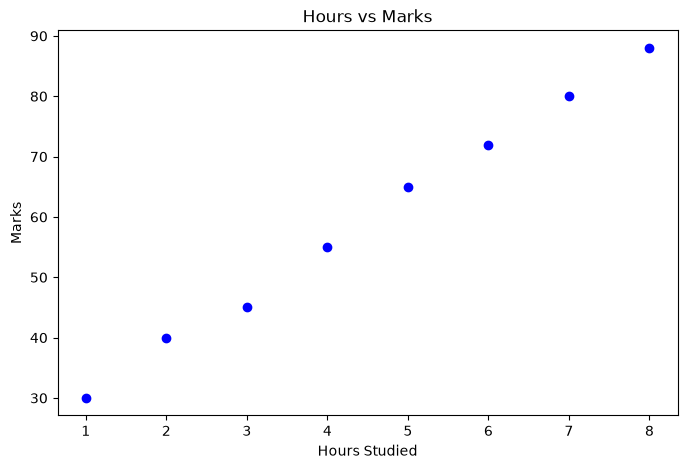

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours"], df["Marks"], color="blue")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

In [42]:
X = df[["Hours"]]
y = df["Marks"]
print(X.head())
print(y.head())

   Hours
0      1
1      2
2      3
3      4
4      5
0    30
1    40
2    45
3    55
4    65
Name: Marks, dtype: int64


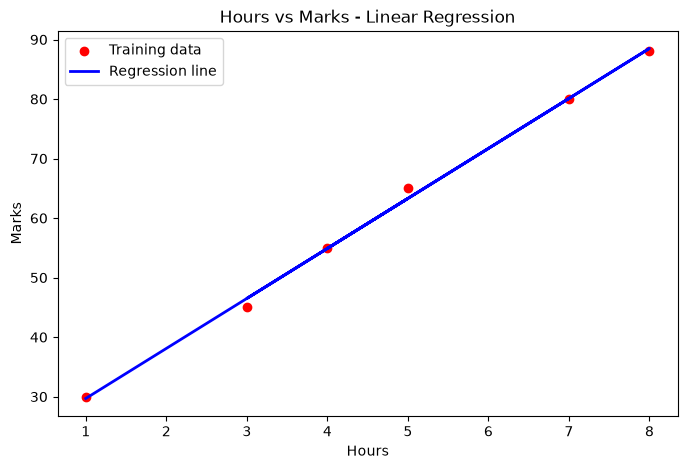

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, Y_train, color="red", label="Training data")
plt.plot(X_train, model.predict(X_train), color="blue",
         label="Regression line", linewidth=2)
plt.legend()
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Hours vs Marks - Linear Regression")
plt.show()


#### Multiple Linear Regression 
#### when one output depends on multiple input variable ,we use MLR

#### ex- House predictions,students 
#### Single LR - y = mx+c
#### Multi LR - y= b0+b1x1+b2x2....b2xn
#### why?#because it has multiple independent variable.
##### y = output
#### b0=intercept
#### b1b2b3... = coefficient
#### x1,x2,x3... = features
